In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
land_polygons = gpd.read_file("/glade/work/rneale/data/US_MAPS/ne_10m_land.shp")

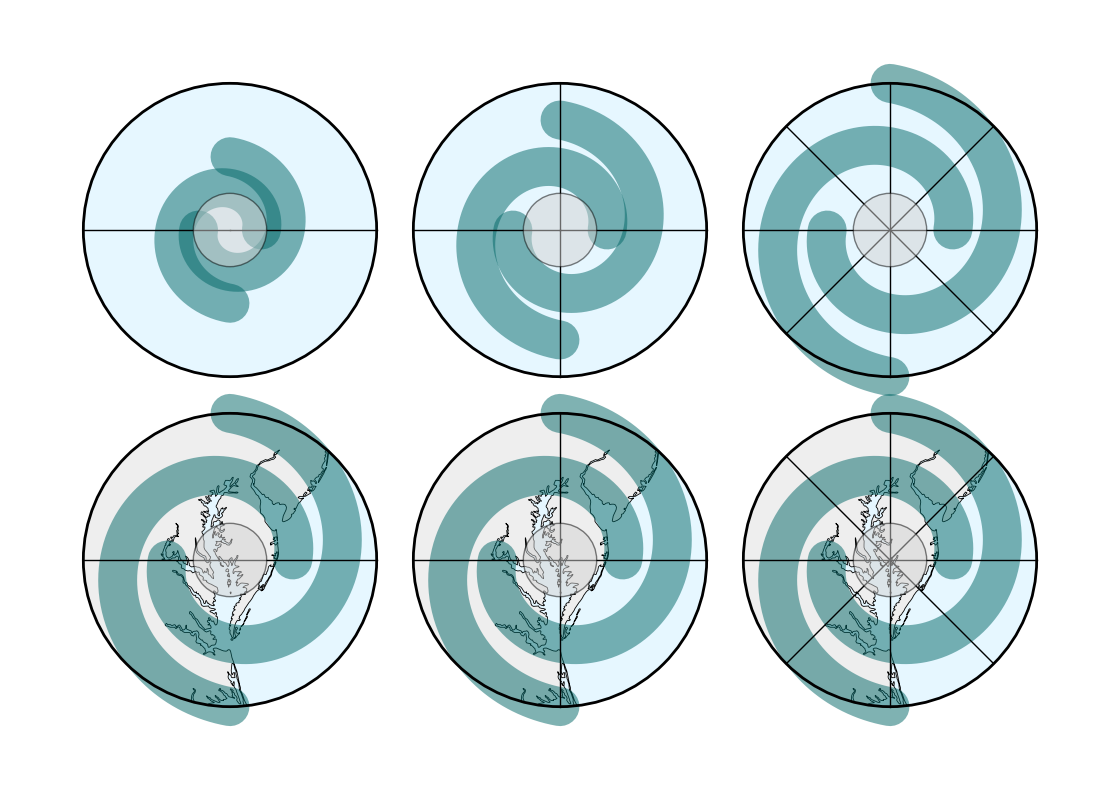

In [42]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from shapely.affinity import scale, translate
from shapely.ops import unary_union
from shapely.geometry import MultiPolygon, Polygon as ShapelyPolygon, Point
from matplotlib.patches import Circle, Polygon as MplPolygon

# -----------------------------
# Parameters
# -----------------------------
R = 4.0
small_fraction = 0.25
spacing = 10 * 0.9          # 10% tighter
row_spacing = 10 * 0.9
north_offset_miles = 50
circle_radius_miles = 200
circle_radius_m = circle_radius_miles * 1609
north_offset_m = north_offset_miles * 1609

# Chesapeake Bay approximate center
lon_center, lat_center = -76.0, 38.9

# -----------------------------
# Load Natural Earth land polygons
# -----------------------------

land_polygons = gpd.read_file("/glade/work/rneale/data/US_MAPS/ne_10m_land.shp")
land_polygons = land_polygons.to_crs(epsg=3857)
land_polygon = unary_union(land_polygons.geometry)

# Project center point
center_point = gpd.GeoSeries([Point(lon_center, lat_center)],
                             crs="EPSG:4326").to_crs(epsg=3857)
lon_center_m, lat_center_m = center_point.iloc[0].x, center_point.iloc[0].y

# -----------------------------
# Helper functions
# -----------------------------
def project_to_circle_shape(geom, center_x, center_y, R, circle_radius_m, center_m, north_offset_m=0):
    geom_shifted = translate(geom, xoff=-center_m[0], yoff=-center_m[1])
    scale_factor = R / circle_radius_m
    geom_scaled = scale(geom_shifted, xfact=scale_factor,
                        yfact=scale_factor, origin=(0,0))
    geom_translated = translate(geom_scaled, xoff=center_x,
                                yoff=center_y + north_offset_m*scale_factor)
    circle_mask = Point(center_x, center_y).buffer(R)
    return geom_translated.intersection(circle_mask)

# -----------------------------
# Draw circle with land & spirals
# -----------------------------
def draw_circle(ax, center_x, center_y, divisions, R,
                draw_land=False, spiral_fraction=1.0):
    # Water background
    ax.add_patch(Circle((center_x, center_y), R,
                        facecolor="#e6f7ff", edgecolor="none", zorder=0))  # super light blue
    
    # Land shading
    if draw_land:
        clipped_land = project_to_circle_shape(
            land_polygon,
            center_x, center_y, R,
            circle_radius_m, (lon_center_m, lat_center_m),
            north_offset_m=north_offset_m
        )
        if isinstance(clipped_land, ShapelyPolygon):
            ax.add_patch(MplPolygon(list(clipped_land.exterior.coords),
                                    facecolor="#eeeeee", edgecolor="black", linewidth=0.6, zorder=1))
        elif isinstance(clipped_land, MultiPolygon):
            for part in clipped_land.geoms:
                ax.add_patch(MplPolygon(list(part.exterior.coords),
                                        facecolor="#eeeeee", edgecolor="black", linewidth=0.6, zorder=1))
    
    # Hurricane spiral bands **on top**
    theta = np.linspace(0, 1.5*np.pi, 400)
    a, b = 0.6, 0.18
    r = a*np.exp(b*theta)
    r = spiral_fraction * R * r / np.max(r)
    for phase in [0, np.pi]:
        ax.plot(center_x + r*np.cos(theta + phase),
                center_y + r*np.sin(theta + phase),
                color="#006666", linewidth=28, alpha=0.5, solid_capstyle="round", zorder=2)

    # Outer circle outline
    ax.add_patch(Circle((center_x, center_y), R, fill=False,
                        linewidth=2.0, zorder=3))

    # Radial lines
    for i in range(divisions):
        angle = 2*np.pi*i/divisions
        x_end = center_x + R*np.cos(angle)
        y_end = center_y + R*np.sin(angle)
        ax.plot([center_x, x_end], [center_y, y_end],
                color="black", linewidth=1.0, zorder=4)

    # Inner transparent circle
    ax.add_patch(Circle((center_x, center_y), small_fraction*R,
                        facecolor="lightgray", edgecolor="black",
                        alpha=0.5, zorder=5))

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(16,10), facecolor="white")
ax.set_facecolor("white")

# Upper row: spiral fractions 50%, 75%, 100%
for cx, divs, frac in zip([0, spacing, 2*spacing],
                          [2,4,8], [0.5, 0.75, 1.0]):
    draw_circle(ax, cx, 0, divs, R, draw_land=False, spiral_fraction=frac)

# Lower row: Chesapeake Bay satellite style
for cx, divs in zip([0, spacing, 2*spacing], [2,4,8]):
    draw_circle(ax, cx, -row_spacing, divs, R, draw_land=True, spiral_fraction=1.0)

ax.set_aspect("equal")
ax.set_xlim(-6, 2*spacing + 6)
ax.set_ylim(-row_spacing - 6, 6)
ax.axis("off")
plt.show()

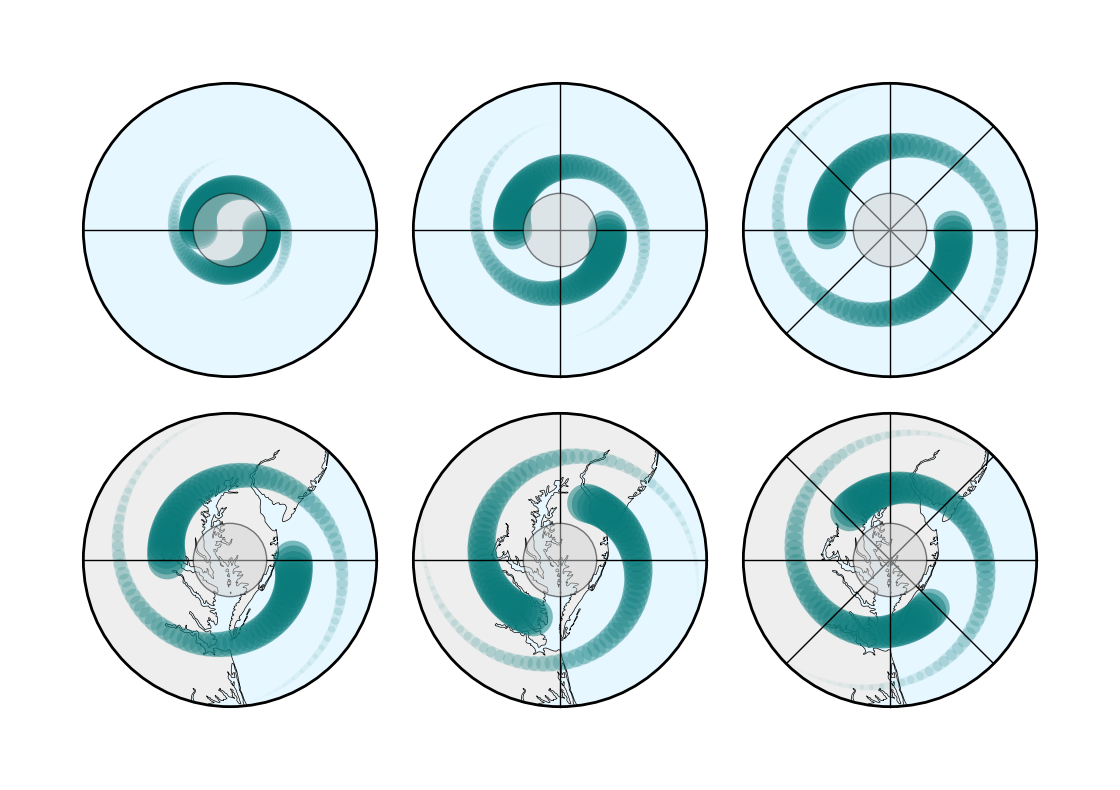

In [46]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from shapely.affinity import scale, translate
from shapely.ops import unary_union
from shapely.geometry import MultiPolygon, Polygon as ShapelyPolygon, Point
from matplotlib.patches import Circle, Polygon as MplPolygon

# -----------------------------
# Parameters
# -----------------------------
R = 4.0
small_fraction = 0.25
spacing = 10 * 0.9
row_spacing = 10 * 0.9

north_offset_miles = 50
circle_radius_miles = 200

circle_radius_m = circle_radius_miles * 1609
north_offset_m = north_offset_miles * 1609

lon_center, lat_center = -76.0, 38.9

# -----------------------------
# Load YOUR land file
# -----------------------------
land_polygons = gpd.read_file(
    "/glade/work/rneale/data/US_MAPS/ne_10m_land.shp"
)
land_polygons = land_polygons.to_crs(epsg=3857)
land_polygon = unary_union(land_polygons.geometry)

center_point = gpd.GeoSeries(
    [Point(lon_center, lat_center)],
    crs="EPSG:4326"
).to_crs(epsg=3857)

lon_center_m = center_point.iloc[0].x
lat_center_m = center_point.iloc[0].y

# -----------------------------
# Projection helper
# -----------------------------
def project_to_circle_shape(geom, center_x, center_y, R,
                            circle_radius_m, center_m,
                            north_offset_m=0):

    geom_shifted = translate(
        geom,
        xoff=-center_m[0],
        yoff=-center_m[1]
    )

    scale_factor = R / circle_radius_m

    geom_scaled = scale(
        geom_shifted,
        xfact=scale_factor,
        yfact=scale_factor,
        origin=(0, 0)
    )

    geom_translated = translate(
        geom_scaled,
        xoff=center_x,
        yoff=center_y + north_offset_m * scale_factor
    )

    circle_mask = Point(center_x, center_y).buffer(R)

    return geom_translated.intersection(circle_mask)

# -----------------------------
# Draw circle
# -----------------------------
def draw_circle(ax, center_x, center_y, divisions, R,
                draw_land=False,
                spiral_fraction=1.0,
                phase_shift_deg=0):

    # Ocean
    ax.add_patch(Circle(
        (center_x, center_y), R,
        facecolor="#e6f7ff",
        edgecolor="none",
        zorder=0
    ))

    # Land
    if draw_land:
        clipped_land = project_to_circle_shape(
            land_polygon,
            center_x, center_y, R,
            circle_radius_m,
            (lon_center_m, lat_center_m),
            north_offset_m=north_offset_m
        )

        if isinstance(clipped_land, ShapelyPolygon):
            ax.add_patch(MplPolygon(
                list(clipped_land.exterior.coords),
                facecolor="#eeeeee",
                edgecolor="black",
                linewidth=0.5,
                zorder=1
            ))
        elif isinstance(clipped_land, MultiPolygon):
            for part in clipped_land.geoms:
                ax.add_patch(MplPolygon(
                    list(part.exterior.coords),
                    facecolor="#eeeeee",
                    edgecolor="black",
                    linewidth=0.5,
                    zorder=1
                ))

    # -----------------------------
    # Tapered + Reversed spiral
    # -----------------------------
    theta = np.linspace(0, 1.5*np.pi, 400)

    a, b = 0.6, 0.18
    r = a * np.exp(b * theta)
    r = spiral_fraction * R * r / np.max(r)

    phase_shift = np.deg2rad(phase_shift_deg)

    # Reverse direction (clockwise)
    theta = -theta

    n_segments = 60
    indices = np.linspace(0, len(theta)-1, n_segments).astype(int)

    for phase in [0, np.pi]:

        for i in range(len(indices)-1):

            i0 = indices[i]
            i1 = indices[i+1]

            taper_fraction = 1 - (i / (len(indices)-1))

            linewidth = 28 * taper_fraction
            alpha = 0.5 * taper_fraction

            ax.plot(
                center_x + r[i0:i1] * np.cos(theta[i0:i1] + phase + phase_shift),
                center_y + r[i0:i1] * np.sin(theta[i0:i1] + phase + phase_shift),
                color="#0a7a7a",
                linewidth=linewidth,
                alpha=alpha,
                solid_capstyle="round",
                zorder=2
            )

    # Outer ring
    ax.add_patch(Circle(
        (center_x, center_y), R,
        fill=False,
        linewidth=2.0,
        zorder=3
    ))

    # Radials
    for i in range(divisions):
        angle = 2 * np.pi * i / divisions
        ax.plot(
            [center_x, center_x + R * np.cos(angle)],
            [center_y, center_y + R * np.sin(angle)],
            color="black",
            linewidth=1.0,
            zorder=4
        )

    # Inner circle
    ax.add_patch(Circle(
        (center_x, center_y),
        small_fraction * R,
        facecolor="lightgray",
        edgecolor="black",
        alpha=0.5,
        zorder=5
    ))

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(16, 10), facecolor="white")
ax.set_facecolor("white")

# Top row
for cx, divs, frac in zip(
        [0, spacing, 2 * spacing],
        [2, 4, 8],
        [0.5, 0.75, 1.0]):

    draw_circle(ax, cx, 0, divs, R,
                draw_land=False,
                spiral_fraction=frac,
                phase_shift_deg=0)

# Bottom row with offsets
bottom_offsets = [0, 65, 130]

for cx, divs, offset in zip(
        [0, spacing, 2 * spacing],
        [2, 4, 8],
        bottom_offsets):

    draw_circle(ax, cx, -row_spacing, divs, R,
                draw_land=True,
                spiral_fraction=1.0,
                phase_shift_deg=offset)

ax.set_aspect("equal")
ax.set_xlim(-6, 2 * spacing + 6)
ax.set_ylim(-row_spacing - 6, 6)
ax.axis("off")

plt.show()